<a href="https://colab.research.google.com/github/nicole-whitlock/games/blob/main/Evaluation_and_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from transformers import TFDistilBertModel
import numpy as np
from tqdm import tqdm
from transformers import DistilBertTokenizer

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [3]:
dir = '/content/drive/MyDrive/ML_models'

In [4]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [5]:
test_input_ids = np.load('/content/drive/MyDrive/ML_models/test_input_ids.npy')
test_attention_mask = np.load('/content/drive/MyDrive/ML_models/test_attention_mask.npy')
test_labels = np.load('/content/drive/MyDrive/ML_models/test_labels.npy')
test_scores = np.load('/content/drive/MyDrive/ML_models/test_original_scores.npy')

In [6]:
MAX_LEN = 128
NUM_CLASSES = 3
BATCH_SIZE = 16

In [7]:
test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': test_input_ids,
        'attention_mask': test_attention_mask
    },
    test_labels
))
test_dataset = test_dataset.batch(BATCH_SIZE)

In [8]:
class DistilBertLayer(tf.keras.layers.Layer):
    def __init__(self, bert_model, **kwargs):
        super(DistilBertLayer, self).__init__(**kwargs)
        self.bert_model = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        bert_output = self.bert_model(input_ids, attention_mask=attention_mask, return_dict=True)
        return bert_output["last_hidden_state"]

def create_model(bert_model, max_len=MAX_LEN, num_classes=NUM_CLASSES):
    # Define inputs
    input_ids = tf.keras.Input(shape=(max_len,), dtype='int32', name='input_ids')
    attention_masks = tf.keras.Input(shape=(max_len,), dtype='int32', name='attention_mask')

    # BERT layer
    bert_output = DistilBertLayer(bert_model)([input_ids, attention_masks])

    # Global average pooling
    pooled_output = tf.keras.layers.GlobalAveragePooling1D()(bert_output)

    # Dropout for regularization
    dropout = tf.keras.layers.Dropout(0.3)(pooled_output)

    # Output layer
    output = tf.keras.layers.Dense(num_classes, activation='softmax')(dropout)

    # Create model
    model = tf.keras.models.Model(inputs={'input_ids': input_ids, 'attention_mask': attention_masks}, outputs=output)

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
base_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')
model = create_model(base_model)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [10]:
sample_input_ids = tf.convert_to_tensor(test_input_ids[:1])
sample_attention_mask = tf.convert_to_tensor(test_attention_mask[:1])
_ = model({'input_ids': sample_input_ids, 'attention_mask': sample_attention_mask})

In [11]:
weights_path = '/content/drive/MyDrive/ML_models/distilbert_layer_sentiment_weights.h5'
model.load_weights(weights_path)

print("Model weights loaded successfully!")


Model weights loaded successfully!


In [13]:
predictions = model.predict(test_dataset)
predicted_classes = np.argmax(predictions, axis=1)

18504/18504 [==============================] - 243s 13ms/step


In [14]:
true_classes = test_labels

In [19]:
# import confusion matrix
from sklearn.metrics import confusion_matrix

In [20]:
cm = confusion_matrix(test_labels, predicted_classes)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

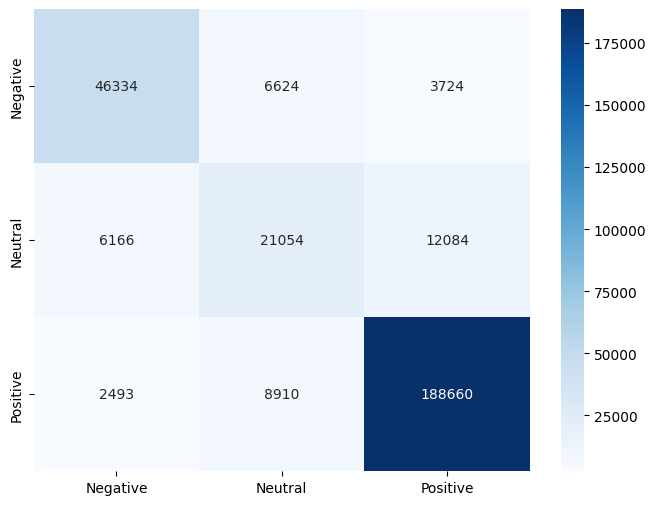

In [22]:
#plot confustion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])

In [ ]:
# Look at mislabeled neutral

In [23]:
mislabeled_indices = np.where(predicted_classes != test_labels)[0]
print(f"Total mislabeled examples: {len(mislabeled_indices)}")

Total mislabeled examples: 40001


In [24]:
def decode_text(input_ids):
    # Remove padding tokens
    input_ids = input_ids[input_ids != 0]
    # Convert back to text
    return tokenizer.decode(input_ids)

In [27]:
num_examples_to_show = min(10, len(mislabeled_indices))

class_names = ['Negative', 'Neutral', 'Positive']
for i in range(num_examples_to_show):
    idx = mislabeled_indices[i]

    # Get the text if possible (if you saved test_quotes or have a way to get original text)
    try:
        text = decode_text(test_input_ids[idx])
    except:
        text = f"Example #{idx}"  # Fallback if original text not available

    true_label = class_names[test_labels[idx]]
    pred_label = class_names[predicted_classes[idx]]
    confidence = predictions[idx][predicted_classes[idx]] * 100
    original_score = test_scores[idx]

    print(f"Example {i+1}:")
    print(f"Text: {text}")
    print(f"True label: {true_label}")
    print(f"Predicted label: {pred_label} (confidence: {confidence:.2f}%)")
    print(f"Original Score: {original_score}")

Example 1:
Text: [CLS] an intriguing idea that the franchise is yet to live up to. [ apr 2012, p. 64 ] [SEP]
True label: Neutral
Predicted label: Positive (confidence: 53.38%)
Original Score: 60.0
Example 2:
Text: [CLS] cuts to the core of an action jrpg, the combat, and does an admirable job of making something worthwhile out of it. [SEP]
True label: Positive
Predicted label: Neutral (confidence: 65.90%)
Original Score: 70.0
Example 3:
Text: [CLS] in the line of fan service duty, dragon ball z : extreme butoden is a well - designed and visually appealing game that is bound to be appreciated by the series'fan base. it risks falling out of touch with the rest of the audience, though, as its cast needs to be enlarged and the lack of an online mode and of a training mode make the experience much more limited than what is usually expected from a fighting game. [SEP]
True label: Neutral
Predicted label: Positive (confidence: 62.21%)
Original Score: 60.0
Example 4:
Text: [CLS] the ability to